In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [2]:
import requests
import pandas as pd

url = 'http://127.0.0.1:8000/'
headers = {
'accept': 'application/json',
'Content-Type': 'application/json'}
response = requests.get('http://127.0.0.1:8000/analyses/', headers=headers)


<Axes: >

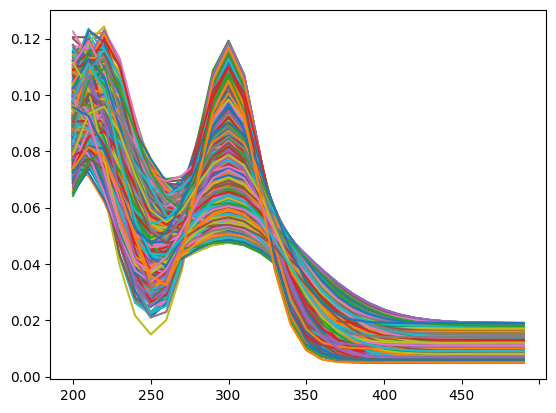

In [3]:
pd.DataFrame([pd.Series(a['Analyses_data'],name=a['Analyse_name']) for a in response.json() if a['Analyse_subname'] == 'UV']).T.plot(legend=False)

In [4]:
data_RAMAN = pd.DataFrame([pd.Series(a['Analyses_data'],name=a['Analyse_name']) for a in response.json() if a['Analyse_subname'] == 'RAMAN'])#.T.plot(legend=False)
data_UV = pd.DataFrame([pd.Series(a['Analyses_data'],name=a['Analyse_name']) for a in response.json() if a['Analyse_subname'] == 'UV'])#.T.plot(legend=False)

In [5]:
import numpy as np
from sklearn.decomposition import PCA


pca_UV = PCA(n_components=3)
weights_UV=pca_UV.fit_transform(data_UV.fillna(0))
pca_RAMAN = PCA(n_components=3)
weights_RAMAN=pca_RAMAN.fit_transform(data_RAMAN.fillna(0))

assert (data_RAMAN.index == data_UV.index).all()

weigths_analysis = np.concatenate([weights_RAMAN,weights_UV],axis=1)
weigths_analysis.shape

(912, 6)

In [6]:
# FastICA: a fast algorithm for Independent Component Analysis.

# from sklearn.datasets import load_digits
# from sklearn.decomposition import FastICA
# X, _ = load_digits(return_X_y=True)
# transformer = FastICA(n_components=7,
#         random_state=0,
#         whiten='unit-variance')
# X_transformed = transformer.fit_transform(X)
# X_transformed.shape

In [7]:
response = requests.get('http://127.0.0.1:8000/OGD/', headers=headers)


In [8]:
metadata = pd.DataFrame(response.json())
metadata.columns

assert (metadata.Batch_OGD_name == data_RAMAN.index).all()

time_columns = ['Batch_OGD_date','Batch_OGD_heure_debut','Batch_OGD_heure_fin']
categorical_columns = ['Batch_OGD_Technicien','Batch_OGD_KC8_batch','Batch_OGD_THF_batch']
numerical_columns = ['Batch_OGD_KC8_masse','Batch_OGD_Temperature','Batch_OGD_Agitation','Batch_OGD_room_HR','Batch_OGD_room_T']

In [9]:
# save data for python script for ml flow on azure

import pickle
with open('ML_Models/data/train.pkl', 'wb') as file: 
    pickle.dump(metadata.iloc[:120,2:], file) 
with open("ML_Models/data/test.pkl", 'wb') as file: 
    pickle.dump(metadata.iloc[40:,2:], file) 


In [10]:
# handeling time variables

timed = metadata[time_columns]
for col in timed.columns:
    timed.loc[:,col] = pd.to_datetime(timed[col])

timed['year'] = pd.DatetimeIndex(timed['Batch_OGD_date']).year.astype(str)
timed['month'] = pd.DatetimeIndex(timed['Batch_OGD_date']).month.astype(str)
timed['time_exfo'] = (timed['Batch_OGD_heure_fin'] - timed['Batch_OGD_heure_debut']) / pd.Timedelta(hours=1)

metadata_timed = pd.concat([metadata,timed],axis=1)

numerical_columns = numerical_columns + ['time_exfo']
categorical_columns = categorical_columns + ['year','month']


/var/folders/dv/gzhyqctn53s9bh23g7tbvl940000gn/T/ipykernel_72422/2575082292.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  timed['year'] = pd.DatetimeIndex(timed['Batch_OGD_date']).year.astype(str)
/var/folders/dv/gzhyqctn53s9bh23g7tbvl940000gn/T/ipykernel_72422/2575082292.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  timed['month'] = pd.DatetimeIndex(timed['Batch_OGD_date']).month.astype(str)
/var/folders/dv/gzhyqctn53s9bh23g7tbvl940000gn/T/ipykernel_72422/2575082292.py:9: SettingWithCopyWarning

In [11]:
# handeling numerical variables
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled = scaler.fit_transform(metadata_timed[numerical_columns])
scaled = pd.DataFrame(scaled)
scaled.columns = numerical_columns


In [12]:
# handeling categorical variables
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder( sparse_output=False)
ohe_data = ohe.fit_transform(metadata_timed[categorical_columns])
ohe_cols = [a for b in ohe.categories_ for a in b]
onehotencoded = pd.DataFrame(data=ohe_data,columns=ohe_cols)
# onehotencoded = pd.get_dummies(metadata_timed[categorical_columns],drop_first=True).reset_index(drop=True)

In [13]:
metadata_ready = pd.concat([metadata['Batch_OGD_name'],scaled,onehotencoded],axis=1)
assert (metadata_ready.Batch_OGD_name == data_RAMAN.index).all()

df_analysis = pd.DataFrame(data=weigths_analysis,index=metadata_ready.Batch_OGD_name)
data_ready = pd.merge(df_analysis,metadata_ready,on='Batch_OGD_name')
data_ready.columns = data_ready.columns.astype(str)

# assess clustering

In [14]:
from sklearn.cluster import KMeans


from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import mutual_info_score, adjusted_rand_score


clust_results = dict()
n_to_fit = round(data_ready.shape[0]*0.6)
n_to_test = round(data_ready.shape[0]*0.4)

for i in range(2,20):
    kmeans = KMeans(n_clusters=i, random_state=0, n_init="auto").fit(data_ready.iloc[:,1:])
    clust_results[i] = dict()
    clust_results[i]['inertia'] = kmeans.inertia_
    clust_results[i]['silhouette'] = silhouette_score(data_ready.iloc[:,1:], kmeans.labels_)
    clust_results[i]['davies_bouldin'] = davies_bouldin_score(data_ready.iloc[:,1:], kmeans.labels_)
    clust_results[i]['calinski_harabasz'] = calinski_harabasz_score(data_ready.iloc[:,1:], kmeans.labels_)


    # check clusturing on part of data
    kmeans = KMeans(n_clusters=i, random_state=0, n_init="auto").fit(data_ready.iloc[:n_to_fit,1:])
    preds = kmeans.predict(data_ready.iloc[-n_to_fit:,1:])

    # clust_results[i] = dict()
    clust_results[i]['mutual_info'] = mutual_info_score(kmeans.labels_[-n_to_test:], preds[:n_to_test])
    clust_results[i]['adjusted_rand'] = adjusted_rand_score(kmeans.labels_[-n_to_test:], preds[:n_to_test])

In [15]:
# train
print("train",data_ready.iloc[:n_to_fit,1:].shape)
# test
print("test_on_train",data_ready.iloc[:n_to_fit,1:][-n_to_test:].shape)

# predict
print("predict",data_ready.iloc[-n_to_fit:,1:].shape)
# test
print("test_on_predict",data_ready.iloc[-n_to_fit:,1:][:n_to_test].shape)

train (547, 966)
test_on_train (365, 966)
predict (547, 966)
test_on_predict (365, 966)


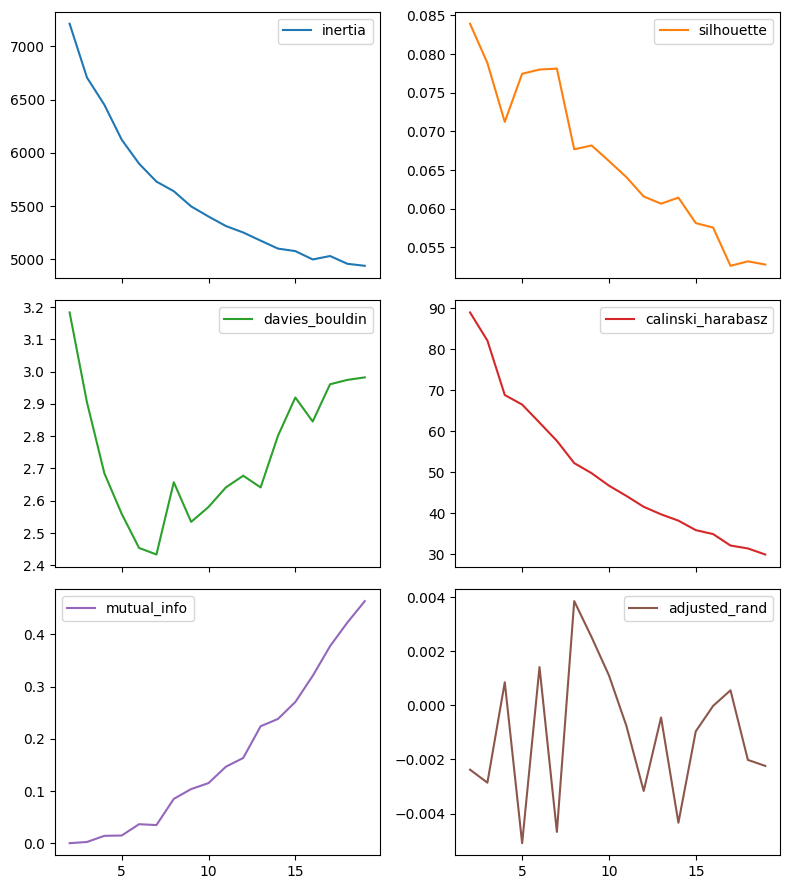

In [16]:
# PLOT results
clust_results = pd.DataFrame(clust_results).T
clust_results.plot(subplots=True,layout=(3,2),figsize=(8,9))
plt.tight_layout()

# create sample and localize it on the 2D map

In [17]:
# make sample

sample_name = 'OGD2501-D'
response = requests.get(f'http://127.0.0.1:8000/OGD/name/{sample_name}', headers=headers)
sample = pd.DataFrame(response.json(),index=[0])


sample_timed = sample[time_columns]
for col in time_columns:
    sample_timed.loc[:,col] = pd.to_datetime(sample_timed[col])

sample_timed['year'] = pd.DatetimeIndex(sample_timed['Batch_OGD_date']).year.astype(str)
sample_timed['month'] = pd.DatetimeIndex(sample_timed['Batch_OGD_date']).month.astype(str)
sample_timed['time_exfo'] = (sample_timed['Batch_OGD_heure_fin'] - sample_timed['Batch_OGD_heure_debut']) / pd.Timedelta(hours=1)

sample_metadata_timed = pd.concat([sample,sample_timed],axis=1)

sample_scaled = scaler.transform(sample_metadata_timed[numerical_columns])
sample_scaled = pd.DataFrame(scaled, columns=numerical_columns,index=[0])

sample_ohe_data = ohe.transform(sample_metadata_timed[categorical_columns])
sample_onehotencoded = pd.DataFrame(data=sample_ohe_data,columns=ohe_cols,index=[0])

sample_metadata_ready = pd.concat([sample['Batch_OGD_name'],sample_scaled,sample_onehotencoded],axis=1)
sample_metadata_ready

/var/folders/dv/gzhyqctn53s9bh23g7tbvl940000gn/T/ipykernel_72422/4089678676.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_timed['year'] = pd.DatetimeIndex(sample_timed['Batch_OGD_date']).year.astype(str)
/var/folders/dv/gzhyqctn53s9bh23g7tbvl940000gn/T/ipykernel_72422/4089678676.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_timed['month'] = pd.DatetimeIndex(sample_timed['Batch_OGD_date']).month.astype(str)
/var/folders/dv/gzhyqctn53s9bh23g7tbvl940000gn/T/ipykernel_72422/408967867

,Batch_OGD_name,Batch_OGD_KC8_masse,Batch_OGD_Temperature,Batch_OGD_Agitation,Batch_OGD_room_HR,Batch_OGD_room_T,time_exfo,LB,LC,RS,...,11,12,2,3,4,5,6,7,8,9
0,OGD2501-D,0.0,-1.183779,-0.141929,-0.301069,-1.147378,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


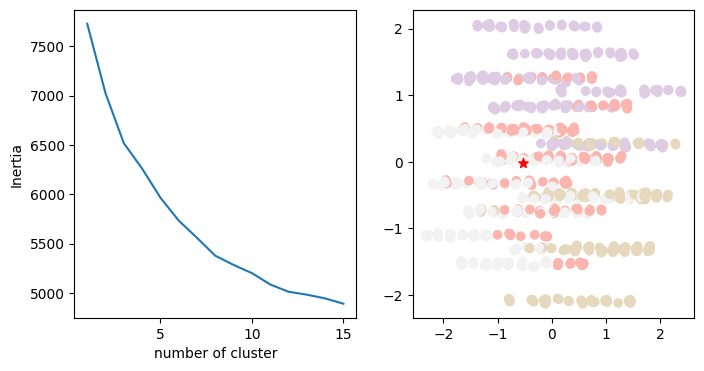

In [18]:
from sklearn.cluster import KMeans
import numpy as np

import numpy as np
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
weights=pca.fit_transform(metadata_ready.iloc[:,1:].fillna(0))
sample_weights = pca.transform(sample_metadata_ready.iloc[:,1:])
inertias=list()
for i in range(1,16):
    kmeans = KMeans(n_clusters=i, random_state=0, n_init="auto").fit(metadata_ready.iloc[:,1:].fillna(0))
    inertias.append(kmeans.inertia_)

kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto").fit(metadata_ready.iloc[:,1:].fillna(0))


f, ax = plt.subplots(1,2,figsize=(8,4))
ax[0].plot(range(1,16),inertias)
ax[0].set_xlabel("number of cluster")
ax[0].set_ylabel("Inertia")
ax[1].scatter(weights[:,0],weights[:,1],c=kmeans.labels_,cmap='Pastel1')
ax[1].scatter(sample_weights[:,0],sample_weights[:,1],c='red',s=50,marker='*')

In [19]:
# sample_name = 'OGD2501-D'
response = requests.get(f'http://127.0.0.1:8000/analyses/name/{sample_name}', headers=headers)
sample = pd.DataFrame(response.json())
sample_UV = pd.DataFrame(sample.loc[sample.Analyse_subname == 'UV','Analyses_data'][0],index=[0])
sample_RAMAN = pd.DataFrame(sample.loc[sample.Analyse_subname == 'RAMAN','Analyses_data'][1],index=[0])

In [20]:
analysis_UV = pca_UV.transform(sample_UV)
analysis_RAMAN = pca_RAMAN.transform(sample_RAMAN)

sample_analysis = np.concatenate([analysis_RAMAN,analysis_UV],axis=1)
sample_ready = pd.merge(pd.DataFrame(sample_analysis, index=[sample_name]),sample_metadata_ready,left_index=True,right_on='Batch_OGD_name').drop(columns='Batch_OGD_name')
sample_ready.columns = sample_ready.columns.astype(str)

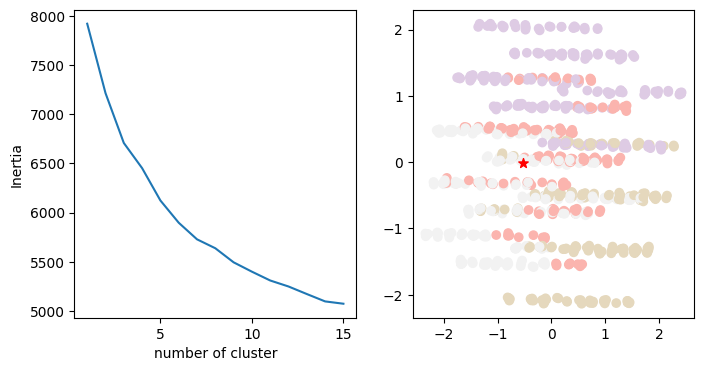

In [21]:
from sklearn.cluster import KMeans
import numpy as np

import numpy as np
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
weights=pca.fit_transform(data_ready.iloc[:,1:].fillna(0))
sample_weights = pca.transform(sample_ready)
inertias=list()
for i in range(1,16):
    kmeans = KMeans(n_clusters=i, random_state=0, n_init="auto").fit(data_ready.iloc[:,1:].fillna(0))
    inertias.append(kmeans.inertia_)

kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto").fit(data_ready.iloc[:,1:].fillna(0))


f, ax = plt.subplots(1,2,figsize=(8,4))
ax[0].plot(range(1,16),inertias)
ax[0].set_xlabel("number of cluster")
ax[0].set_ylabel("Inertia")
ax[1].scatter(weights[:,0],weights[:,1],c=kmeans.labels_,cmap='Pastel1')
ax[1].scatter(sample_weights[:,0],sample_weights[:,1],c='red',s=50,marker='*')

### first look for a number of cluster >1 and <5
#### then calculate scores

In [ ]:
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans, AffinityPropagation, MeanShift, SpectralClustering, AgglomerativeClustering, DBSCAN, HDBSCAN, OPTICS, Birch
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

# Prépare données 
X = data_ready.iloc[:,1:].fillna(0)
# Dictionnaire pour stocker les scores
scores = {}
all_labels = {}
# Fonction pour évaluer et stocker les scores
def evaluate_clustering(name, algorithm, params):
    try:
        labels = algorithm(**params).fit_predict(X)
        silhouette = silhouette_score(X, labels)
        davies_bouldin = davies_bouldin_score(X, labels)
        calinski_harabasz = calinski_harabasz_score(X, labels)
        scores[name] = {'silhouette': silhouette, 'davies_bouldin': davies_bouldin, 'calinski_harabasz':calinski_harabasz}
        all_labels[name] = labels
    except Exception as e:
        scores[name] = {'error': str(e)}

# Évaluation des algorithmes
evaluate_clustering('KMeans', KMeans, {'n_clusters': 2})
# evaluate_clustering('AffinityPropagation', AffinityPropagation, {'damping': 0.5})
# evaluate_clustering('MeanShift', MeanShift, {'bandwidth': 2})
evaluate_clustering('SpectralClustering', SpectralClustering, {'n_clusters': 2})
evaluate_clustering('AgglomerativeClustering', AgglomerativeClustering, {'n_clusters': 2})
# evaluate_clustering('DBSCAN', DBSCAN, {'eps': 0.5})
# evaluate_clustering('HDBSCAN', HDBSCAN, {'min_cluster_size': 5})
# evaluate_clustering('OPTICS', OPTICS, {'min_samples': 2})
evaluate_clustering('GaussianMixture', GaussianMixture, {'n_components': 2})
evaluate_clustering('Birch', Birch, {'n_clusters': 2})

# Affichage des scores
scores


{'KMeans': {'silhouette': np.float64(0.08427070796442966),
  'davies_bouldin': np.float64(3.180591697574314),
  'calinski_harabasz': np.float64(88.98147617135703)},
 'SpectralClustering': {'silhouette': np.float64(0.05662922724631634),
  'davies_bouldin': np.float64(3.351151374170339),
  'calinski_harabasz': np.float64(60.933495436830356)},
 'AgglomerativeClustering': {'silhouette': np.float64(0.08801676538888754),
  'davies_bouldin': np.float64(3.0609110166307474),
  'calinski_harabasz': np.float64(85.45263767426968)},
 'GaussianMixture': {'silhouette': np.float64(0.08272949358772436),
  'davies_bouldin': np.float64(3.194349019188787),
  'calinski_harabasz': np.float64(88.5477038916037)},
 'Birch': {'silhouette': np.float64(0.08801676538888754),
  'davies_bouldin': np.float64(3.0609110166307474),
  'calinski_harabasz': np.float64(85.45263767426968)}}

/Applications/anaconda3/envs/CarbonWaters/lib/python3.13/site-packages/sklearn/cluster/_affinity_propagation.py:140: ConvergenceWarning: Affinity propagation did not converge, this model may return degenerate cluster centers and labels.
  warnings.warn(


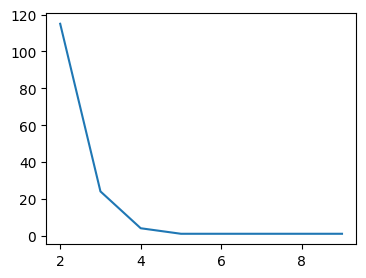

In [ ]:
# AffinityPropagation
res=dict()
for dampling in np.arange(0.9,1,0.01):
    res[dampling] = len(np.unique(AffinityPropagation(damping= dampling).fit(data_ready.iloc[:,1:].fillna(0)).labels_))
pd.Series(res).plot(figsize=(4,3))
plt.show()
import random
damping = random.choice([k for k, v in res.items() if v < 100 and v > 1])
labels = AffinityPropagation(damping= damping).fit(data_ready.iloc[:,1:].fillna(0)).labels_
all_labels['AffinityPropagation'] = labels
silhouette = silhouette_score(X, labels)
davies_bouldin = davies_bouldin_score(X, labels)
calinski_harabasz = calinski_harabasz_score(X, labels)
scores['AffinityPropagation'] = {'silhouette': silhouette, 'davies_bouldin': davies_bouldin, 'calinski_harabasz':calinski_harabasz}

# OPTICS
res=dict()
for min_samples in np.arange(2,10,1):
    res[min_samples] = len(np.unique(OPTICS(min_samples= min_samples).fit(data_ready.iloc[:,1:].fillna(0)).labels_))
pd.Series(res).plot(figsize=(4,3))
plt.show()
min_samples = random.choice([k for k, v in res.items() if v < 5 and v > 1])
labels = OPTICS(min_samples= min_samples).fit(data_ready.iloc[:,1:].fillna(0)).labels_
all_labels['OPTICS'] = labels
silhouette = silhouette_score(X, labels)
davies_bouldin = davies_bouldin_score(X, labels)
calinski_harabasz = calinski_harabasz_score(X, labels)
scores['OPTICS'] = {'silhouette': silhouette, 'davies_bouldin': davies_bouldin, 'calinski_harabasz':calinski_harabasz}

# HDBSCAN
res=dict()
for min_cluster_size in np.arange(2,20,1):
    res[min_cluster_size] = len(np.unique(HDBSCAN(min_cluster_size= min_cluster_size).fit(data_ready.iloc[:,1:].fillna(0)).labels_))
pd.Series(res).plot(figsize=(4,3))
plt.show()
min_cluster_size = random.choice([k for k, v in res.items() if v < 5 and v > 1])
labels = HDBSCAN(min_cluster_size= min_cluster_size).fit(data_ready.iloc[:,1:].fillna(0)).labels_
all_labels['HDBSCAN'] = labels
silhouette = silhouette_score(X, labels)
davies_bouldin = davies_bouldin_score(X, labels)
calinski_harabasz = calinski_harabasz_score(X, labels)
scores['HDBSCAN'] = {'silhouette': silhouette, 'davies_bouldin': davies_bouldin, 'calinski_harabasz':calinski_harabasz}

# DBSCAN
res=dict()
for eps in np.arange(1,100,10):
    res[eps] = len(np.unique(DBSCAN(min_samples=eps).fit(data_ready.iloc[:,1:].fillna(0)).labels_))
pd.Series(res).plot(figsize=(4,3))
plt.show()



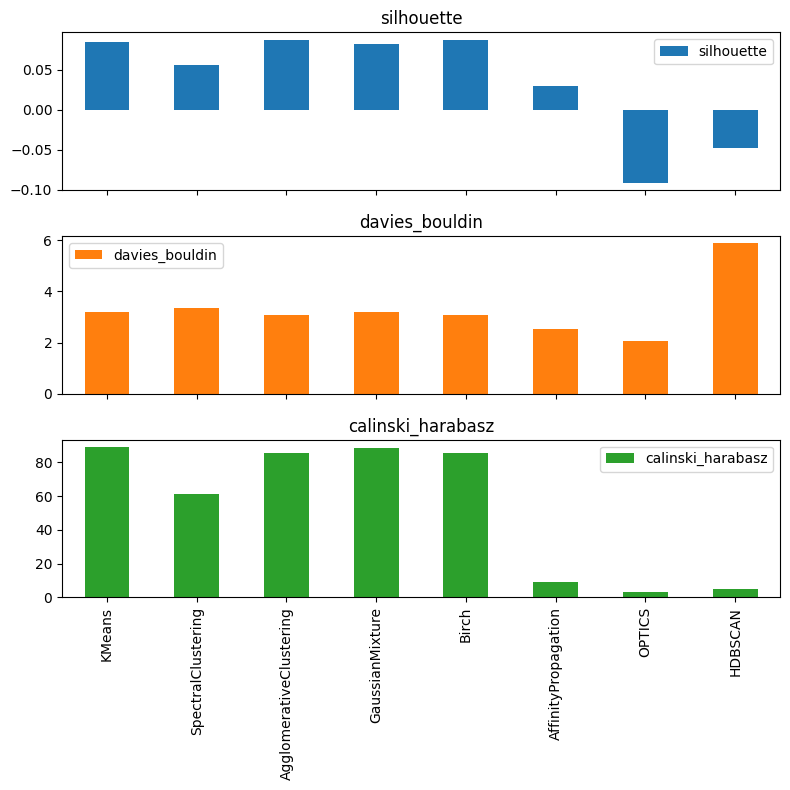

In [37]:
pd.DataFrame(scores).T.plot(kind='bar',subplots=True,layout=(3,1),figsize=(8,8))
plt.tight_layout()

In [ ]:
scores

{'KMeans': {'silhouette': np.float64(0.0919098255958864),
  'davies_bouldin': np.float64(3.0045882232698267),
  'calinski_harabasz': np.float64(45.09430785223813)},
 'SpectralClustering': {'silhouette': np.float64(0.039079596911282224),
  'davies_bouldin': np.float64(1.8505048317518304),
  'calinski_harabasz': np.float64(4.598422592432718)},
 'AgglomerativeClustering': {'silhouette': np.float64(0.07192759889274247),
  'davies_bouldin': np.float64(3.241042825577241),
  'calinski_harabasz': np.float64(33.683571881653286)},
 'GaussianMixture': {'silhouette': np.float64(0.08883604105922409),
  'davies_bouldin': np.float64(3.045959289854721),
  'calinski_harabasz': np.float64(43.90153294580719)},
 'Birch': {'silhouette': np.float64(0.07192759889274247),
  'davies_bouldin': np.float64(3.241042825577241),
  'calinski_harabasz': np.float64(33.683571881653286)},
 'AffinityPropagation': {'silhouette': np.float64(0.04345290829259781),
  'davies_bouldin': np.float64(3.523978744712101)},
 'OPTICS':




data train XXXXXXXXxx   --> initialise the clusturing on first 80%  == KMeans model 1

data test  xxxxxxXXXX   --> test clusturing on last 40% == KMeans model 2


make score verif on 60->80% (rand score)

make score assess on 80->100% 

Inertia (I) Sum of squared distances of samples to their closest cluster center, weighted by the sample weights if provided.
Interpretation : Lower is better

Silhouette Score (S) for a data point i is calculated as:
Interpretation: It ranges from -1 (poor clustering) to +1 (perfect clustering). A score close to 1 suggests well-separated clusters.

Davies-Bouldin Index (DB) is calculated as the average similarity between each cluster and its closest neighbor:
Interpretation: Lower numbers suggest better clustering solutions.

Calinski-Harabasz Index (CH) is calculated as:
Interpretation: Higher numbers suggest better-defined clusters.

Adjusted Rand Index (ARI) is calculated as:
Interpretation: It ranges from -1 to 1, where 1 indicates perfect clustering, 0 indicates random clustering, and negative values suggest poor clustering.

MI between true labels Y and predicted labels Z is calculated as:
Interpretation: High MI values indicate better alignment between clusters and true labels, signifying good clustering results.
